# 01 · Ingestion & EV segmentation (tasks 1–2) · **EXPLORE**

**Owner:** Jaime · **Status:** sandbox · **Reads on:** base dataset from `00` · **Feeds:** step 3 (functional connectivity)

**Delivers.** Tasks **(1) ingestion** (load the parcellated WM BOLD) and
**(2) EV segmentation** (split frames 0-back vs 2-back), plus shared artifacts (subject
split, region table, behaviour target). Reusable logic in `ingestion.py`, whose code
style follows the official NMA loader
([`load_hcp_task_with_behaviour`](https://compneuro.neuromatch.io/projects/fMRI/load_hcp_task_with_behaviour.html);
local copy under `official/.../projects/fMRI/`).

**Base dataset:** Finalist A — `hcp_task_with_behaviour` (100 subjects). For Finalist B, the
same functions re-run with `HCP_DIR` at the new paths (see `00`).

**Provenance.** Glasser et al. 2016 (360 ROIs); Cole-Anticevic / Ji et al. 2019 (12 networks); HCP Data Use Terms
apply. Full access details at top of `02`.

## Setup

In [1]:
from pathlib import Path
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
JAIME = cwd if (cwd / "datasets.py").exists() else cwd / "sandbox" / "jaime"
ROOT = JAIME.parents[1]                          # the-gammas repo root
sys.path.insert(0, str(JAIME))
import datasets as ds, preprocessing as pp, evaluation as ev

DATA = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT / "data"))
A, B = ds.spec_a(DATA), ds.spec_b(DATA)
subjects = ds.list_subjects(A)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})
C_0BK, C_2BK = "#2e7d5b", "#b5462f"              # green = low load, red = high load (threaded through the notebook)
f"{len(subjects)} subjects · {ds.N_PARCELS} ROIs · TR = {ds.TR}s"

'100 subjects · 360 ROIs · TR = 0.72s'

## Task 1 · BOLD time series

Each subject has a `(360 × frames)` parcellated BOLD matrix per run. The **EV files** say which frames belong to
which condition. The WM task interleaves **8 conditions** = 2 load levels (0-back / 2-back) × 4 stimulus categories.
To see it, plot a few ROIs' signal with the condition blocks shaded.

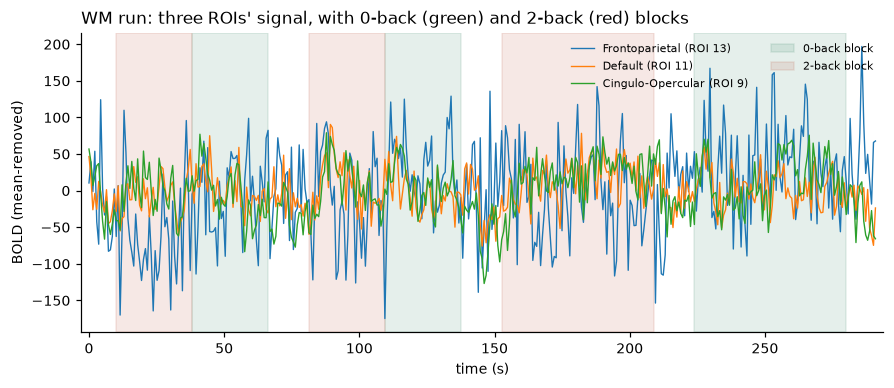

In [2]:
subj = subjects[0]
ts = ds.load_timeseries(A, subj, 0)          # (360, 405)
reg = pp.region_table(A)

# one ROI from each of the three networks the hypothesis cares about
pick = {net: reg.index[reg.network == net][0] for net in ["Frontoparietal", "Default", "Cingulo-Opercular"]}
f0 = pp.condition_frames(A, subj, 0, "0back")
f2 = pp.condition_frames(A, subj, 0, "2back")

t = np.arange(ts.shape[1]) * ds.TR
fig, ax = plt.subplots(figsize=(8.2, 3.6))
for net, roi in pick.items():
    ax.plot(t, ts[roi], lw=0.9, label=f"{net} (ROI {roi})")

def shade(frames, color, label):
    if len(frames) == 0:
        return
    for k, blk in enumerate(np.split(frames, np.where(np.diff(frames) > 1)[0] + 1)):   # contiguous blocks
        ax.axvspan(blk[0] * ds.TR, (blk[-1] + 1) * ds.TR, color=color, alpha=0.12,
                   label=label if k == 0 else None)

shade(f0, C_0BK, "0-back block"); shade(f2, C_2BK, "2-back block")
ax.set_xlabel("time (s)"); ax.set_ylabel("BOLD (mean-removed)")
ax.set_title("WM run: three ROIs' signal, with 0-back (green) and 2-back (red) blocks", loc="left")
ax.legend(frameon=False, fontsize=7.5, ncol=2, loc="upper right")
ax.margins(x=0.01); fig.tight_layout(); plt.show()

The shaded blocks are the task alternating between low and high memory load. **Task 2** is exactly this: select
the frames under each load, so step 3 can build one connectivity matrix per condition.

## Task 2 · Segmenting 0-back vs 2-back

`load_condition_timeseries` pools the 4 categories of a load level and concatenates both runs (LR+RL), doubling the
frames for a more stable connectivity estimate. The two load levels **must not share frames**. This `(360 × n_frames)`
matrix per subject per condition **is what we hand to step 3**.

In [3]:
m0 = pp.condition_timeseries(A, subj, "0back")
m2 = pp.condition_timeseries(A, subj, "2back")
overlap_1run = len(np.intersect1d(f0, f2))
pd.DataFrame({
    "0-back": [m0.shape[1], f"{m0.shape}"],
    "2-back": [m2.shape[1], f"{m2.shape}"],
}, index=["frames/condition (LR+RL)", "matrix shape → step 3"]).assign(
    **{"0-back ∩ 2-back overlap (1 run)": overlap_1run})

,0-back,2-back,0-back ∩ 2-back overlap (1 run)
frames/condition (LR+RL),312,312,0
matrix shape → step 3,"(360, 312)","(360, 312)",0


## Prediction target (`Stats.txt`)

Official helpers don't load behaviour, so `ingestion.py` owns the `Stats.txt` parser (`parse_stats` →
`load_behaviour`). It averages accuracy (ACC) and reaction time (RT) over the 4 categories and both runs. We
recommend **`acc_2bk`** — the high-load accuracy, where subjects genuinely differ.

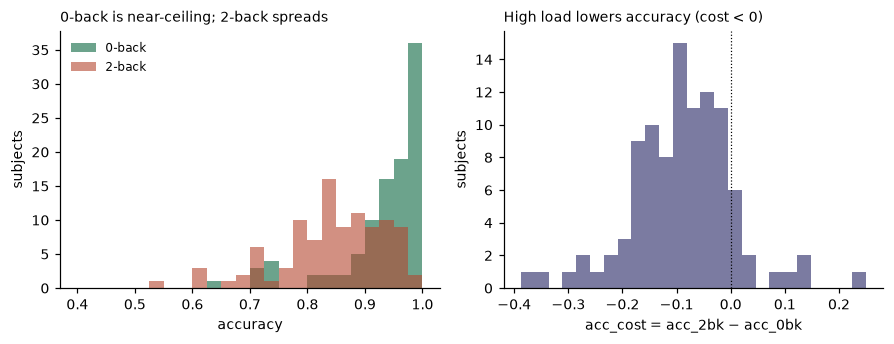

,acc_0bk,acc_2bk,acc_cost,rt_2bk
mean,0.927,0.839,-0.088,1032.301
std,0.077,0.091,0.095,119.747
min,0.638,0.538,-0.388,714.378
max,1.000,0.988,0.250,1257.795


In [4]:
beh = pp.behaviour_table(A)

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.2))
axes[0].hist(beh.acc_0bk, bins=np.linspace(0.4, 1, 25), color=C_0BK, alpha=0.7, label="0-back")
axes[0].hist(beh.acc_2bk, bins=np.linspace(0.4, 1, 25), color=C_2BK, alpha=0.6, label="2-back")
axes[0].set_xlabel("accuracy"); axes[0].set_ylabel("subjects")
axes[0].set_title("0-back is near-ceiling; 2-back spreads", loc="left", fontsize=9)
axes[0].legend(frameon=False, fontsize=8)
axes[1].hist(beh.acc_cost, bins=25, color="#5a5a8a", alpha=0.8)
axes[1].axvline(0, color="k", lw=0.8, ls=":")
axes[1].set_xlabel("acc_cost = acc_2bk − acc_0bk"); axes[1].set_ylabel("subjects")
axes[1].set_title("High load lowers accuracy (cost < 0)", loc="left", fontsize=9)
fig.tight_layout(); plt.show()

beh[["acc_0bk", "acc_2bk", "acc_cost", "rt_2bk"]].describe().round(3).loc[["mean", "std", "min", "max"]]

`acc_2bk` spans ≈0.54–0.99 with no missing values — real between-subject variance to predict. `acc_cost` sits
below zero for most subjects, the expected effect of memory load.

## Anti-leakage subject split

The deliverable is prediction on **held-out subjects**. If any frame from a test subject reaches training, the score
is meaningless. Rule: **split by subject**, never by frame/run. One canonical split is shared so all six of us
evaluate on the same held-out subjects; the builder asserts disjointness and that CV folds partition the train set.

In [5]:
split = ev.make_split(A)                 # validated internally
pd.DataFrame({
    "value": [split["n_train"], split["n_test"], split["cv_folds"], split["seed"],
              set(split["train"]).isdisjoint(split["test"])],
}, index=["train subjects", "test subjects", "CV folds", "seed", "train/test disjoint"])

,value
train subjects,80
test subjects,20
CV folds,5
seed,42
train/test disjoint,True


## Shared artifacts (staging)

Small, canonical files → committed later. In the sandbox they go to `artifacts_staging/` (gitignored) until the team
agrees how to share them.

In [6]:
OUT = JAIME / "artifacts_staging"; OUT.mkdir(exist_ok=True)
reg.to_csv(OUT / "regions.csv", index=False)
beh.to_csv(OUT / "behaviour.csv", index=False)
ev.save_split(split, OUT / "splits.json")
sorted(p.name for p in OUT.glob("*") if p.suffix in {".csv", ".json"})

['behaviour.csv', 'regions.csv', 'splits.json']

## Hand-off to step 3

| Artifact | Shape / form | Consumer |
|---|---|---|
| `load_condition_timeseries(subj, "0back"/"2back")` | `(360 × 312)` BOLD per subject/condition | step 3 (FC) |
| `regions.csv` | 360 rows: ROI → network → hemisphere | all steps |
| `splits.json` | 80/20 by subject + 5 CV folds | step 6 (prediction) |
| `behaviour.csv` | 100 rows × targets (`acc_2bk` default) | step 6 (target) |

**Verified, closed:** target = `acc_2bk` (all subjects, wide spread); 312 frames/condition (LR+RL); 0/2-back frames
disjoint; network labels de-truncated. **Team-level, still open:** dataset A vs B (see `00`), graph thresholding,
prediction model. A full step-by-step EDA of both finalists is in `02`.